In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Tesla.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1692 non-null   object 
 1   Open       1692 non-null   float64
 2   High       1692 non-null   float64
 3   Low        1692 non-null   float64
 4   Close      1692 non-null   float64
 5   Volume     1692 non-null   int64  
 6   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 92.7+ KB


In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1692 non-null   datetime64[ns]
 1   Open       1692 non-null   float64       
 2   High       1692 non-null   float64       
 3   Low        1692 non-null   float64       
 4   Close      1692 non-null   float64       
 5   Volume     1692 non-null   int64         
 6   Adj Close  1692 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 92.7 KB


In [4]:
df.describe()

,Date,Open,High,Low,Close,Volume,Adj Close
count,1692,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03,1692.000000
mean,2013-11-06 02:53:37.021276416,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658
min,2010-06-29 00:00:00,16.139999,16.629999,14.980000,15.800000,1.185000e+05,15.800000
25%,2012-03-01 18:00:00,30.000000,30.650000,29.215000,29.884999,1.194350e+06,29.884999
50%,2013-11-05 12:00:00,156.334999,162.370002,153.150002,158.160004,3.180700e+06,158.160004
75%,2015-07-14 06:00:00,220.557495,224.099999,217.119999,220.022503,5.662100e+06,220.022503
max,2017-03-17 00:00:00,287.670013,291.420013,280.399994,286.040009,3.716390e+07,286.040009
std,NaN,94.309923,95.694914,92.855227,94.313187,4.295971e+06,94.313187


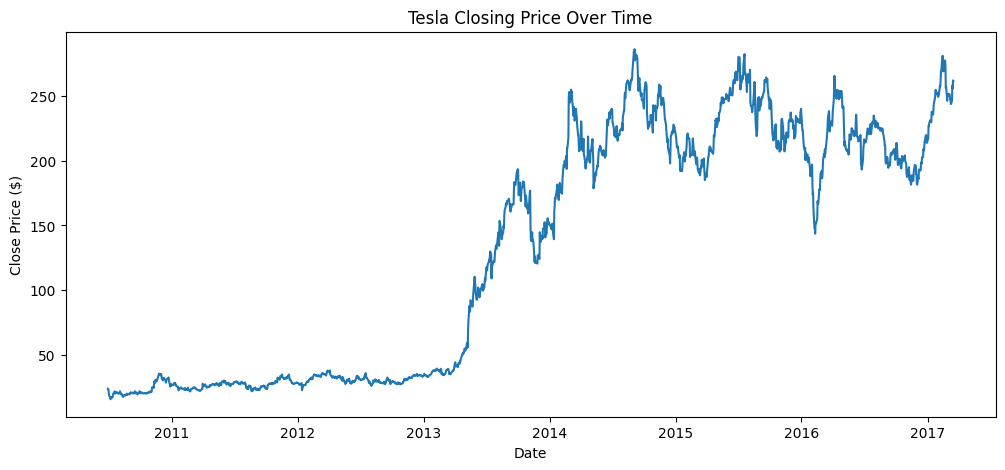

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'])
plt.title('Tesla Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.show()

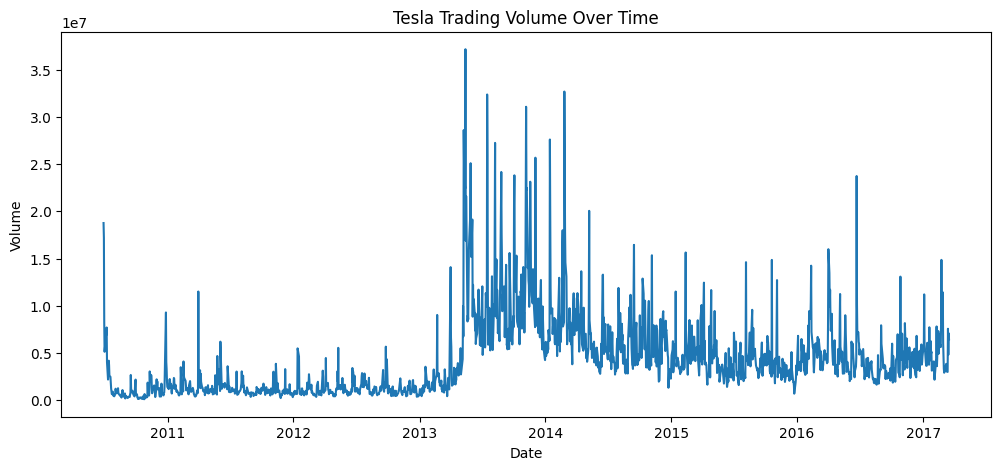

In [6]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Volume'])
plt.title('Tesla Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

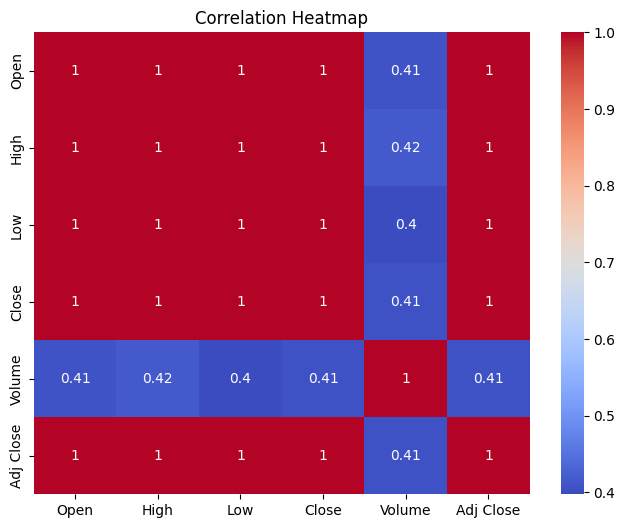

In [7]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df[['Open','High','Low','Close','Volume','Adj Close']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

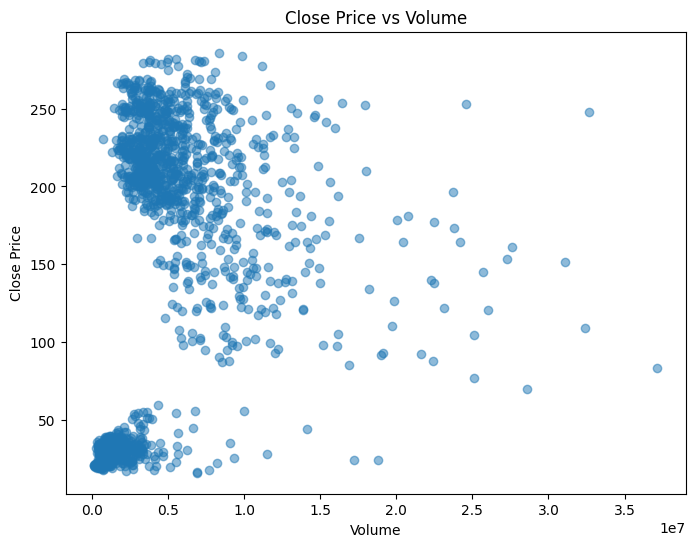

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(df['Volume'], df['Close'], alpha=0.5)
plt.xlabel('Volume')
plt.ylabel('Close Price')
plt.title('Close Price vs Volume')
plt.show()

In [10]:
df['Target'] = df['Close'].shift(-1)  # next day's close
df = df.dropna()

In [11]:
from sklearn.model_selection import train_test_split

features = ['Open', 'High', 'Low', 'Close', 'Volume']
X = df[features]
y = df['Target']

split_idx = int(len(df) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [12]:
X_train.shape

(1352, 5)

In [13]:
X_test.shape

(338, 5)

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))

print("R2:", r2_score(y_test, y_pred))

MAE: 3.662115664981611
R2: 0.9583637764698395


In [15]:
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 5.005083962470995


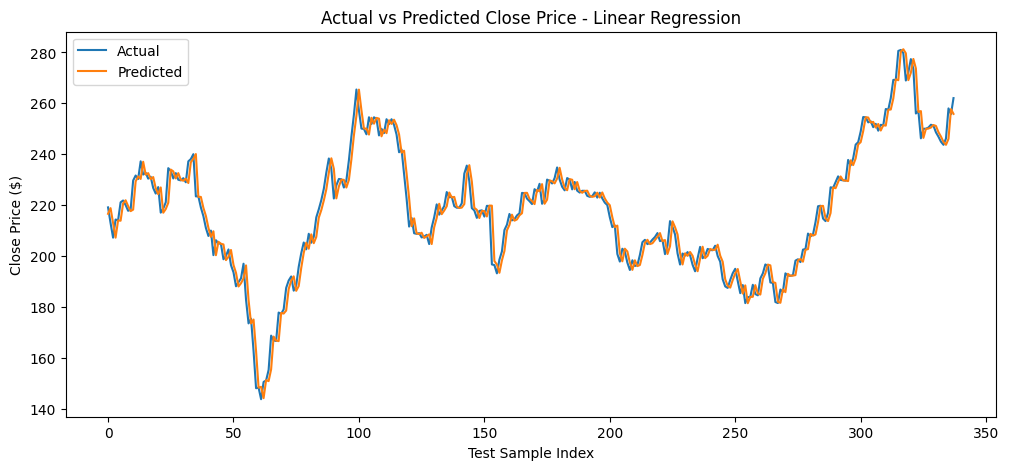

In [18]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title('Actual vs Predicted Close Price - Linear Regression')
plt.xlabel('Test Sample Index')
plt.ylabel('Close Price ($)')
plt.legend()
plt.show()

In [19]:
from sklearn.ensemble import RandomForestRegressor

model2 = RandomForestRegressor(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred2)))
print("R2:", r2_score(y_test, y_pred2))

MAE: 4.553302309230772
RMSE: 6.113250932613527
R2: 0.9378854930425828


In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='neg_mean_absolute_error')
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

y_pred_tuned = grid.best_estimator_.predict(X_test)
print("Tuned MAE:", mean_absolute_error(y_test, y_pred_tuned))
print("Tuned RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tuned)))
print("Tuned R2:", r2_score(y_test, y_pred_tuned))

Best params: {'max_depth': 5, 'n_estimators': 100}
Tuned MAE: 4.06524776304784
Tuned RMSE: 5.504412264404163
Tuned R2: 0.9496417645089881


In [21]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 3.662115664981611
RMSE: 5.005083962470995
R2: 0.9583637764698395


In [22]:
from sklearn.ensemble import GradientBoostingRegressor

model3 = GradientBoostingRegressor(random_state=42)
model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred3))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred3)))
print("R2:", r2_score(y_test, y_pred3))

MAE: 4.1288936822478925
RMSE: 5.653422286058682
R2: 0.9468783629903883


In [23]:
importances = pd.Series(model1.coef_, index=features)
print(importances.sort_values(ascending=False))

Close     9.267959e-01
Low       9.014682e-02
High      1.813475e-02
Volume    5.799438e-08
Open     -3.607306e-02
dtype: float64


In [24]:
import joblib

joblib.dump(model1, 'tesla_stock_model.pkl')

['tesla_stock_model.pkl']

In [25]:
loaded_model = joblib.load('tesla_stock_model.pkl')
sample = X_test.iloc[[0]]
print("Predicted:", loaded_model.predict(sample))
print("Actual:", y_test.iloc[0])

Predicted: [216.55969627]
Actual: 219.080002
